In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import scipy.io
import matplotlib.pyplot as plt

MAT_NAME   = "tst_1.mat"
MARKER_CH  = -1      # last column  = LSL marker   (change if the summary below disagrees)
PHOTO_CH   = -2      # second-last  = photodiode / g.TRIGbox digital input
FLASH_CODE, CAL_DARK, CAL_LIGHT, END_CODE = 20, 5, 6, 255
REFRACTORY = 0.300   # s; edges of the same kind closer than this are one event (min SOA is 0.6 s)
MATCH_WIN  = 0.250   # s; a flash marker is paired with a photodiode onset within +/- this window

mat_path = next((p for p in (Path("../data") / MAT_NAME, Path("data") / MAT_NAME) if p.exists()), None)
assert mat_path is not None, f"{MAT_NAME} not found in ../data or data"

if h5py.is_hdf5(mat_path):                       # MATLAB v7.3 = HDF5
    with h5py.File(mat_path, "r") as f:
        eeg = f["EEG_data"][()]
else:
    eeg = scipy.io.loadmat(mat_path)["EEG_data"]
eeg = np.asarray(eeg, dtype=float)
if eeg.shape[0] < eeg.shape[1]:                  # make it samples x channels
    eeg = eeg.T

t = eeg[:, 0]
fs = 1.0 / np.median(np.diff(t))
marker = np.rint(eeg[:, MARKER_CH]).astype(int)
photo_raw = eeg[:, PHOTO_CH]

print(f"{mat_path}  ->  {eeg.shape[0]} samples x {eeg.shape[1]} columns, "
      f"{t[-1] - t[0]:.1f} s, fs = {fs:.1f} Hz (1 sample = {1000 / fs:.2f} ms)")
print("\nLast 4 columns (check that marker and photodiode are where expected):")
for c in range(eeg.shape[1] - 4, eeg.shape[1]):
    u = np.unique(eeg[:, c])
    desc = f"values {u.astype(int).tolist()}" if u.size <= 12 else f"{u.size} distinct values"
    print(f"  col {c}: min {eeg[:, c].min():.4g}, max {eeg[:, c].max():.4g}, {desc}")

../data/tst_1.mat  ->  168770 samples x 67 columns, 281.3 s, fs = 600.0 Hz (1 sample = 1.67 ms)

Last 4 columns (check that marker and photodiode are where expected):
  col 63: min -3.551e+05, max -3.544e+05, 12568 distinct values
  col 64: min -3.563e+05, max -3.562e+05, 1577 distinct values
  col 65: min 0, max 6.554e+04, values [0, 65536]
  col 66: min 0, max 255, values [0, 5, 6, 7, 9, 20, 255]


In [2]:
def onsets(mask, refractory_s):
    """Sample indices where `mask` turns True, ignoring re-triggers within the refractory time."""
    idx = np.flatnonzero(mask & ~np.r_[False, mask[:-1]])
    keep, last = [], -np.inf
    for i in idx:
        if t[i] - last >= refractory_s:
            keep.append(i)
        last = t[i]                              # any re-trigger extends the refractory period
    return np.array(keep, dtype=int), idx.size

rows = []
for code in [c for c in np.unique(marker) if c != 0]:
    ev, n_raw = onsets(marker == code, REFRACTORY)
    for i in ev:
        seg = marker[i:i + int(REFRACTORY * fs)]
        span = (np.flatnonzero(seg == code)[-1] + 1) / fs * 1000
        rows.append({"code": int(code), "sample": i, "time_s": t[i], "plateau_ms": span,
                     "raw_edges": n_raw / max(len(ev), 1)})
events = pd.DataFrame(rows).sort_values("sample").reset_index(drop=True)

summary = events.groupby("code").agg(n=("code", "size"), first_s=("time_s", "min"),
                                     plateau_ms_median=("plateau_ms", "median"),
                                     plateau_ms_min=("plateau_ms", "min"),
                                     plateau_ms_max=("plateau_ms", "max"),
                                     raw_edges_per_event=("raw_edges", "first")).round(2)
print(summary.to_string())
print("\nExpected: 9 (start), 5-6-5 (calibration), 7 (flash block), 20 x n_flashes, 255 (end).")
print("raw_edges_per_event > 1 means the latched code was recorded with gaps (0s inside the plateau).")

flash_idx = events.loc[events.code == FLASH_CODE, "sample"].to_numpy()
flash_t = t[flash_idx]

        n  first_s  plateau_ms_median  plateau_ms_min  plateau_ms_max  raw_edges_per_event
code                                                                                      
5       2    86.15              84.17           83.33           85.00                  1.0
6       1    88.61              83.33           83.33           83.33                  1.0
7       1    93.52              83.33           83.33           83.33                  1.0
9       1     7.00              56.67           56.67           56.67                  1.0
20    300    95.18              83.33           81.67           85.00                  1.0
255     1   281.28               1.67            1.67            1.67                  1.0

Expected: 9 (start), 5-6-5 (calibration), 7 (flash block), 20 x n_flashes, 255 (end).
raw_edges_per_event > 1 means the latched code was recorded with gaps (0s inside the plateau).


In [3]:
thr = (photo_raw.min() + photo_raw.max()) / 2
photo_hi = photo_raw > thr

def level_between(t0, t1, skip=0.5):
    seg = photo_hi[(t >= t0 + skip) & (t < t1 - 0.1)]
    return seg.mean() if seg.size else np.nan

cal = events[events.code.isin([CAL_DARK, CAL_LIGHT])].reset_index(drop=True)
light_is_high = None
if list(cal.code) == [CAL_DARK, CAL_LIGHT, CAL_DARK]:
    dark1 = level_between(cal.time_s[0], cal.time_s[1])
    light = level_between(cal.time_s[1], cal.time_s[2])
    dark2 = level_between(cal.time_s[2], cal.time_s[2] + (cal.time_s[2] - cal.time_s[1]))
    print(f"Fraction of samples HIGH: dark {dark1:.2f} | light {light:.2f} | dark {dark2:.2f}")
    if abs(light - np.nanmean([dark1, dark2])) > 0.5:
        light_is_high = light > 0.5
if light_is_high is None:                        # fallback: the square is ON ~1/3 of the flash block
    blk = photo_hi[(t >= flash_t[0]) & (t <= flash_t[-1])]
    light_is_high = blk.mean() < 0.5
    print("Calibration not usable -> polarity inferred from the flash block duty cycle "
          f"(HIGH {blk.mean():.0%} of the time).")
print(f"Polarity: square ON = photodiode {'HIGH' if light_is_high else 'LOW'}")

square_on = photo_hi if light_is_high else ~photo_hi
on_idx, n_raw_on = onsets(square_on, REFRACTORY)
on_t = t[on_idx]
in_block = (on_t >= flash_t[0] - MATCH_WIN) & (on_t <= flash_t[-1] + MATCH_WIN)
print(f"Photodiode onsets: {on_idx.size} in total, {in_block.sum()} inside the flash block "
      f"({flash_t.size} flash markers); raw edges {n_raw_on}")

Fraction of samples HIGH: dark 0.00 | light 0.47 | dark 0.85
Calibration not usable -> polarity inferred from the flash block duty cycle (HIGH 38% of the time).
Polarity: square ON = photodiode HIGH
Photodiode onsets: 284 in total, 244 inside the flash block (300 flash markers); raw edges 315


In [4]:
rows = []
for k, (mi, mt) in enumerate(zip(flash_idx, flash_t), start=1):
    j = np.argmin(np.abs(on_t - mt)) if on_t.size else None
    hit = j is not None and abs(on_t[j] - mt) <= MATCH_WIN
    delay = (on_t[j] - mt) * 1000 if hit else np.nan
    on_ms = np.nan
    if hit:                                      # how long the square stayed on (expected 250 ms)
        off = np.flatnonzero(~square_on[on_idx[j]:on_idx[j] + int(fs)])
        on_ms = off[0] / fs * 1000 if off.size else np.nan
    rows.append({"flash": k, "marker_t": mt, "diode_t": on_t[j] if hit else np.nan,
                 "delay_ms": delay, "square_on_ms": on_ms})
res = pd.DataFrame(rows)
d = res.delay_ms.dropna()

print(f"Flashes with a photodiode onset: {d.size}/{len(res)} ({d.size / len(res):.1%})")
print(f"Square ON duration: median {res.square_on_ms.median():.1f} ms "
      f"(min {res.square_on_ms.min():.1f}, max {res.square_on_ms.max():.1f})")
mad_sd = 1.4826 * np.median(np.abs(d - d.median()))
print("\n=== delay = photodiode onset - marker onset (positive: light after marker) ===")
print(f"  LATENCY  mean {d.mean():7.2f} ms   median {d.median():7.2f} ms")
print(f"  JITTER   SD   {d.std():7.2f} ms   robust SD (MAD) {mad_sd:.2f} ms")
print(f"  range    {d.min():.2f} .. {d.max():.2f} ms   "
      f"5th-95th percentile {d.quantile(.05):.2f} .. {d.quantile(.95):.2f} ms")
print(f"  resolution: 1 sample = {1000 / fs:.2f} ms")
print("\nDelay values and counts (ms):")
print(d.round(2).value_counts().sort_index().to_string())

Flashes with a photodiode onset: 201/300 (67.0%)
Square ON duration: median 281.7 ms (min 11.7, max 546.7)

=== delay = photodiode onset - marker onset (positive: light after marker) ===
  LATENCY  mean   -4.49 ms   median  -13.33 ms
  JITTER   SD    143.94 ms   robust SD (MAD) 177.91 ms
  range    -248.33 .. 248.33 ms   5th-95th percentile -213.33 .. 233.33 ms
  resolution: 1 sample = 1.67 ms

Delay values and counts (ms):
delay_ms
-248.33    1
-246.67    1
-243.33    1
-240.00    1
-238.33    1
-235.00    1
-233.33    1
-228.33    1
-226.67    1
-218.33    1
-213.33    1
-211.67    1
-210.00    1
-206.67    1
-203.33    1
-200.00    1
-198.33    1
-196.67    1
-193.33    1
-191.67    1
-188.33    2
-183.33    1
-181.67    2
-180.00    1
-178.33    1
-176.67    1
-175.00    1
-173.33    2
-171.67    1
-170.00    2
-166.67    1
-161.67    1
-158.33    1
-156.67    1
-151.67    2
-148.33    1
-145.00    1
-141.67    2
-138.33    1
-136.67    1
-133.33    1
-131.67    1
-128.33    2
-126

Drift: -12.332 ms per minute (-37.05 ms over the flash block)


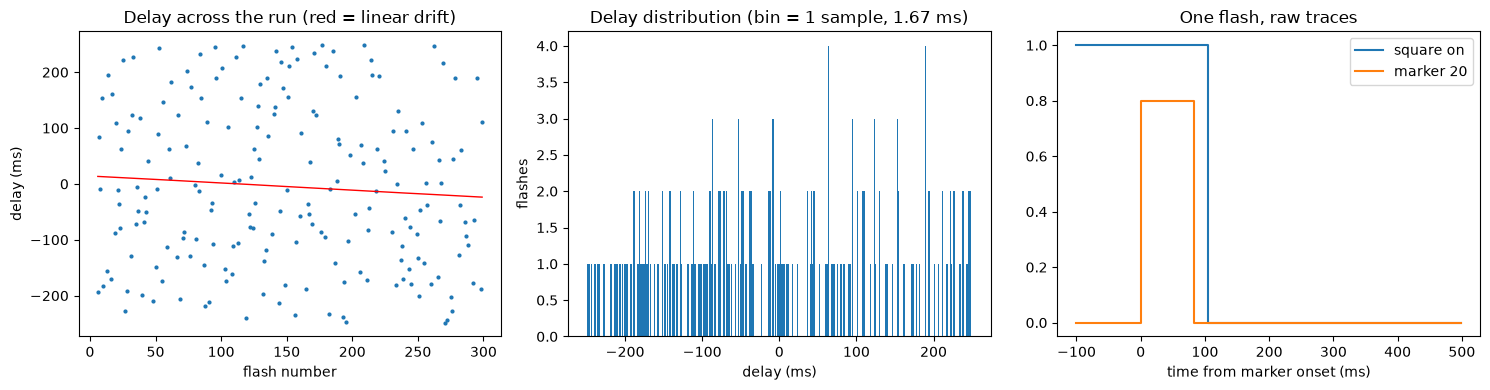

In [5]:
ok = res.dropna(subset=["delay_ms"])
slope, intercept = np.polyfit(ok.marker_t - ok.marker_t.iloc[0], ok.delay_ms, 1)
print(f"Drift: {slope * 60:+.3f} ms per minute "
      f"({slope * (ok.marker_t.iloc[-1] - ok.marker_t.iloc[0]):+.2f} ms over the flash block)")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ok.flash, ok.delay_ms, ".", ms=4)
ax[0].plot(ok.flash, intercept + slope * (ok.marker_t - ok.marker_t.iloc[0]), "r-", lw=1)
ax[0].set(xlabel="flash number", ylabel="delay (ms)", title="Delay across the run (red = linear drift)")
step = 1000 / fs
bins = np.arange(d.min() - step / 2, d.max() + step, step)
ax[1].hist(d, bins=bins)
ax[1].set(xlabel="delay (ms)", ylabel="flashes", title=f"Delay distribution (bin = 1 sample, {step:.2f} ms)")
i0 = flash_idx[min(5, flash_idx.size - 1)]
w = slice(i0 - int(0.1 * fs), i0 + int(0.5 * fs))
ax[2].step((t[w] - t[i0]) * 1000, square_on[w].astype(int), where="post", label="square on")
ax[2].step((t[w] - t[i0]) * 1000, (marker[w] == FLASH_CODE) * 0.8, where="post", label="marker 20")
ax[2].set(xlabel="time from marker onset (ms)", title="One flash, raw traces")
ax[2].legend()
plt.tight_layout()
plt.show()

Calibration: photodiode ON  1.492 s after marker 6 (white square on)
             photodiode OFF 2.088 s after the second marker 5 (square off)

Strongest offset: +635 ms, shared by 15 of 300 flashes (typical bin elsewhere: 4)
Flashes paired at that offset: 47/300 (15.7%)
  LATENCY  mean 635.53 ms   median 633.33 ms
  JITTER   SD   27.70 ms   range 585.00 .. 693.33 ms
  drift    -10.43 ms per minute


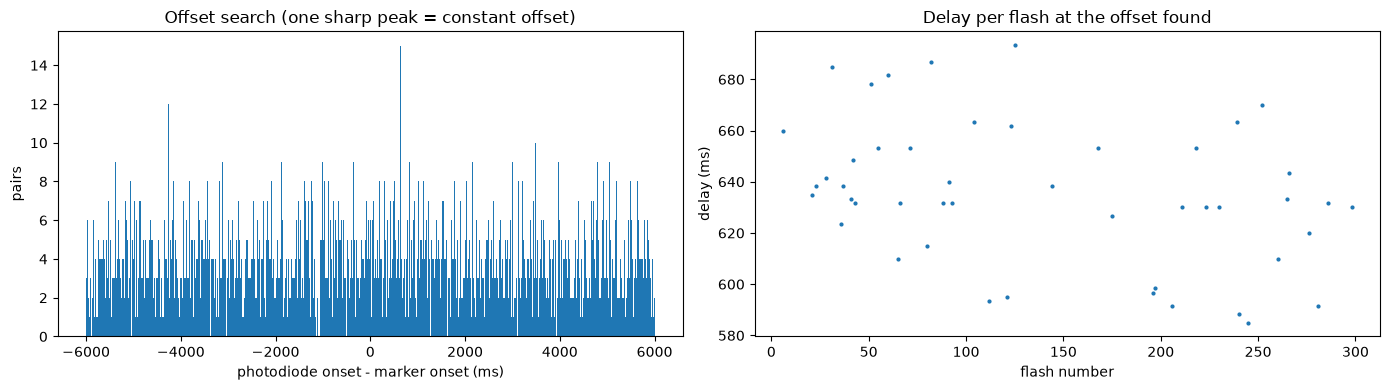

In [6]:
MAX_LAG = 6.0        # s; search range for a constant offset
BIN     = 0.010      # s; histogram bin for the search
PAIR_WIN = 0.060     # s; pairing window around the offset found

# calibration: when did the photodiode actually follow the 3 s white square?
cal = events[events.code.isin([CAL_DARK, CAL_LIGHT])].reset_index(drop=True)
if list(cal.code) == [CAL_DARK, CAL_LIGHT, CAL_DARK]:
    i_light = np.searchsorted(t, cal.time_s[1]); i_dark = np.searchsorted(t, cal.time_s[2])
    rise = np.flatnonzero(square_on[i_light:] & ~square_on[i_light - 1:-1][:square_on[i_light:].size])
    fall = np.flatnonzero(~square_on[i_dark:] & square_on[i_dark - 1:-1][:square_on[i_dark:].size])
    print(f"Calibration: photodiode ON  {rise[0] / fs:.3f} s after marker 6 (white square on)")
    print(f"             photodiode OFF {fall[0] / fs:.3f} s after the second marker 5 (square off)")

# all photodiode-onset minus flash-marker differences; a constant offset shows up as one sharp peak
diffs = (on_t[None, :] - flash_t[:, None]).ravel()
diffs = diffs[np.abs(diffs) <= MAX_LAG]
edges_h = np.arange(-MAX_LAG, MAX_LAG + BIN, BIN)
counts, _ = np.histogram(diffs, bins=edges_h)
k = counts.argmax()
lag0 = (edges_h[k] + edges_h[k + 1]) / 2
print(f"\nStrongest offset: {lag0 * 1000:+.0f} ms, shared by {counts[k]} of {flash_t.size} flashes "
      f"(typical bin elsewhere: {np.median(counts):.0f})")

rows = []
for n, mt in enumerate(flash_t, start=1):
    j = np.argmin(np.abs(on_t - (mt + lag0)))
    dly = on_t[j] - mt
    rows.append({"flash": n, "marker_t": mt, "delay_ms": dly * 1000 if abs(dly - lag0) <= PAIR_WIN else np.nan})
res2 = pd.DataFrame(rows)
d2 = res2.delay_ms.dropna()
print(f"Flashes paired at that offset: {d2.size}/{len(res2)} ({d2.size / len(res2):.1%})")
if d2.size > 10:
    print(f"  LATENCY  mean {d2.mean():.2f} ms   median {d2.median():.2f} ms")
    print(f"  JITTER   SD   {d2.std():.2f} ms   range {d2.min():.2f} .. {d2.max():.2f} ms")
    g = res2.dropna()
    sl = np.polyfit(g.marker_t - g.marker_t.iloc[0], g.delay_ms, 1)[0]
    print(f"  drift    {sl * 60:+.2f} ms per minute")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(edges_h[:-1] * 1000, counts, width=BIN * 1000, align="edge")
ax[0].set(xlabel="photodiode onset - marker onset (ms)", ylabel="pairs", title="Offset search (one sharp peak = constant offset)")
ax[1].plot(res2.flash, res2.delay_ms, ".", ms=4)
ax[1].set(xlabel="flash number", ylabel="delay (ms)", title="Delay per flash at the offset found")
plt.tight_layout(); plt.show()

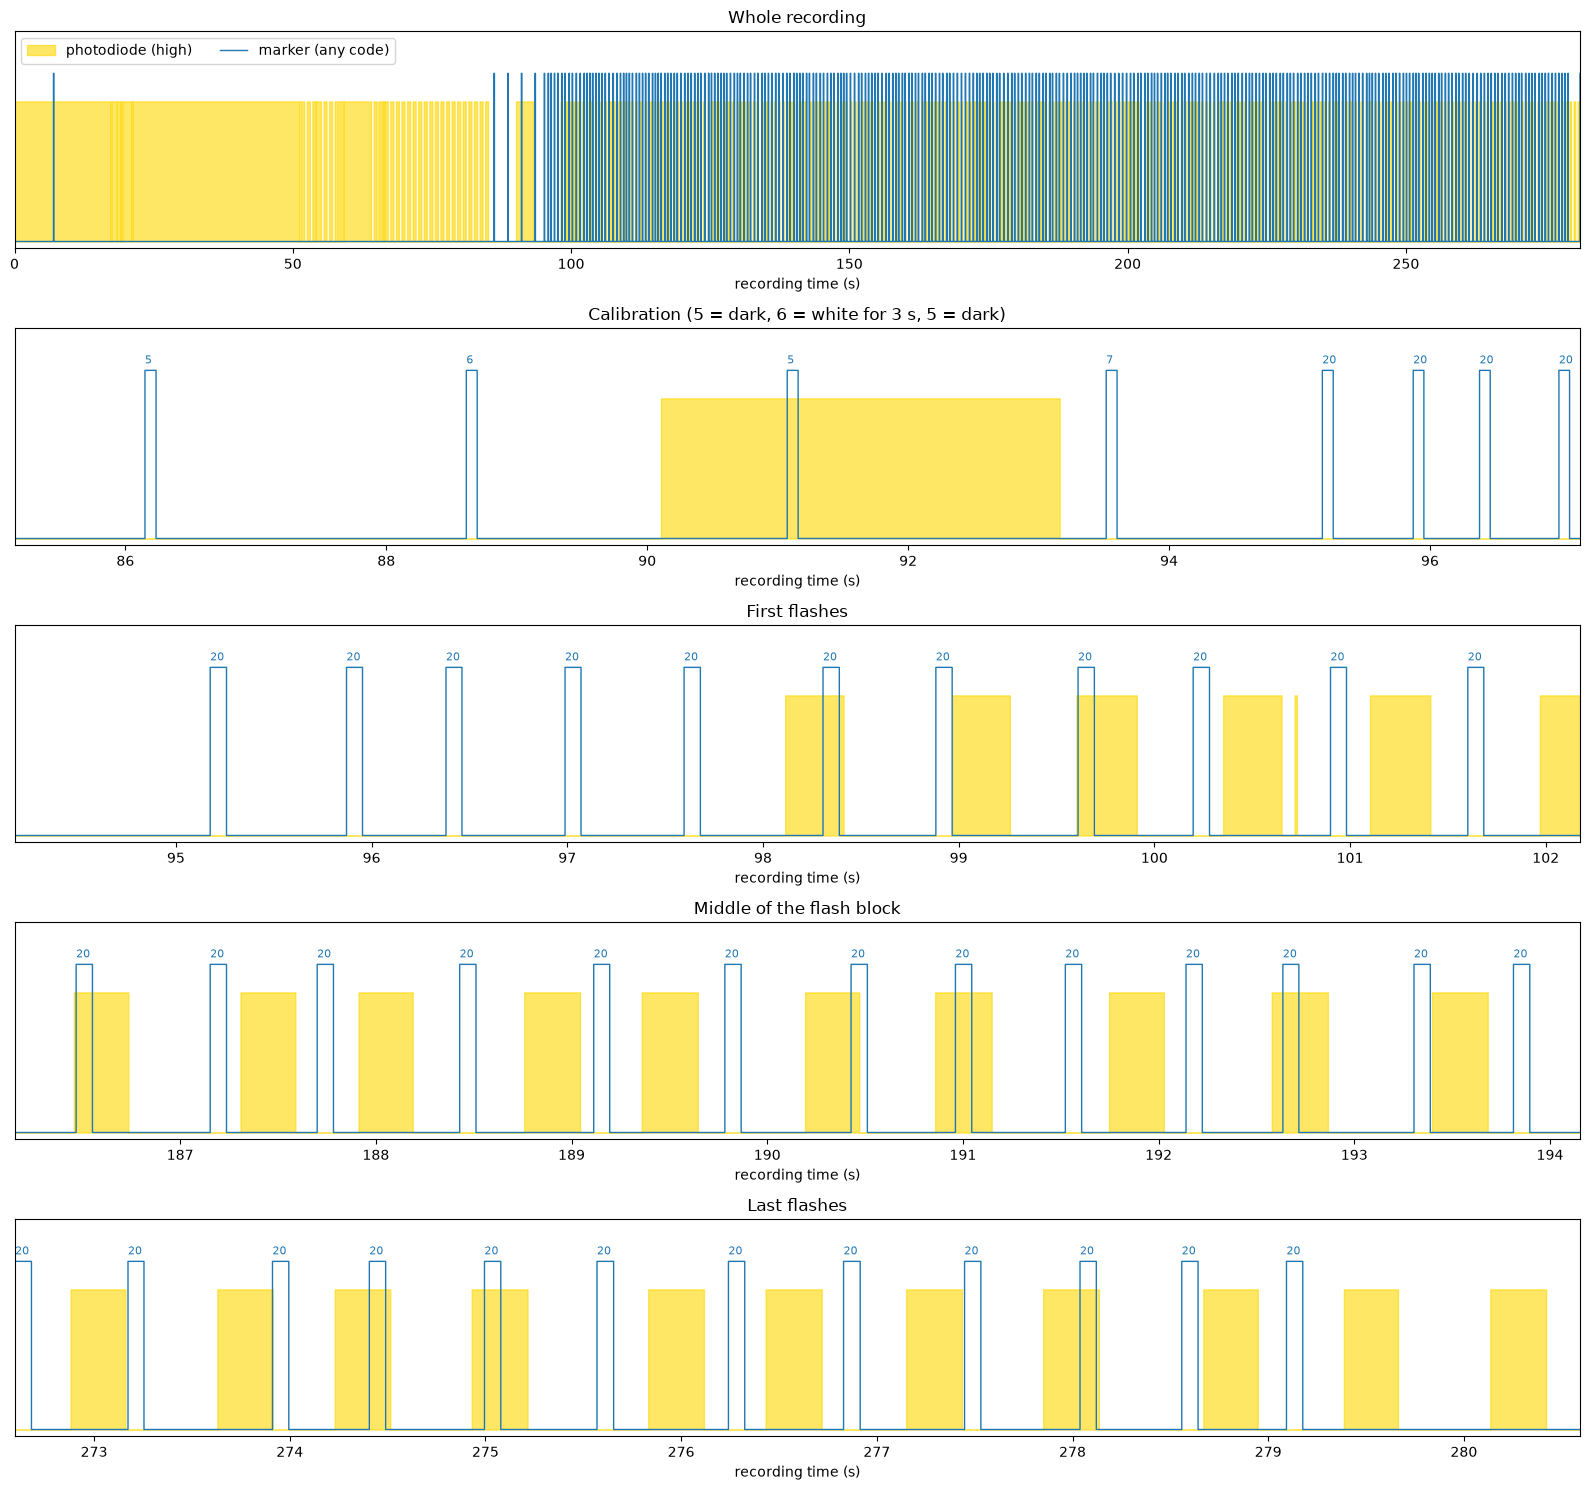

Flash markers:     300 onsets, gap between onsets median 605 ms (min 493, max 742)
Photodiode onsets: 247 after the first flash marker, gap median 731 ms (min 365, max 902)


In [7]:
ZOOM = 8.0           # s; width of each zoomed panel
photo01 = (photo_raw > thr).astype(int)          # raw photodiode level, 0 = low, 1 = high
t_cal   = events.loc[events.code == CAL_DARK, "time_s"].min()
windows = [("Whole recording", t[0], t[-1]),
           ("Calibration (5 = dark, 6 = white for 3 s, 5 = dark)", t_cal - 1, t_cal + 11),
           ("First flashes", flash_t[0] - 1, flash_t[0] - 1 + ZOOM),
           ("Middle of the flash block", flash_t[len(flash_t) // 2] - 1, flash_t[len(flash_t) // 2] - 1 + ZOOM),
           ("Last flashes", flash_t[-1] + 1.5 - ZOOM, flash_t[-1] + 1.5)]

fig, axes = plt.subplots(len(windows), 1, figsize=(16, 3 * len(windows)))
for ax, (title, t0, t1) in zip(axes, windows):
    w = (t >= t0) & (t <= t1)
    ax.fill_between(t[w], 0, photo01[w], step="post", color="gold", alpha=0.6, label="photodiode (high)")
    ax.step(t[w], (marker[w] > 0) * 1.2, where="post", color="tab:blue", lw=1, label="marker (any code)")
    if t1 - t0 < 60:                              # label each marker with its code in the zooms
        for _, e in events[(events.time_s >= t0) & (events.time_s <= t1)].iterrows():
            ax.text(e.time_s, 1.25, str(int(e.code)), color="tab:blue", fontsize=8, ha="left")
    ax.set(title=title, xlim=(t0, t1), ylim=(-0.05, 1.5), yticks=[], xlabel="recording time (s)")
axes[0].legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

gaps_m = np.diff(flash_t)
gaps_p = np.diff(on_t[(on_t > flash_t[0])])
print(f"Flash markers:     {flash_t.size} onsets, gap between onsets median {np.median(gaps_m) * 1000:.0f} ms "
      f"(min {gaps_m.min() * 1000:.0f}, max {gaps_m.max() * 1000:.0f})")
print(f"Photodiode onsets: {gaps_p.size + 1} after the first flash marker, gap median {np.median(gaps_p) * 1000:.0f} ms "
      f"(min {gaps_p.min() * 1000:.0f}, max {gaps_p.max() * 1000:.0f})")